# Calibrating images

## Find out proper serial ports

In [46]:
import time
from enderscope import SerialUtils, Stage
ports = SerialUtils.serial_ports()
stageport = ports[0]
print (ports)

['/dev/ttyUSB0', '/dev/ttyACM0', '/dev/ttyAMA10']


## Initialiaze stage

In [47]:
s = Stage(stageport, 115200)
s.safe_home()
s.move_absolute(0,0,20)
s.get_position()

(0.0, 0.0, 20.0)

## Initialize camera

In [48]:
# starts, or restarts Raspberry Pi camera preview window
from picamera2 import Picamera2
try:
    cam
except NameError:
    pass
else:
    cam.close()
cam = Picamera2()

cam.start(show_preview=True)
# uncomment following lines to disable auto white balance and auto exposure
# and manually set camera parameters
cam.set_controls({'AwbEnable':True,'AeEnable':False})
cam.set_controls({'ExposureTime':20000, 'AnalogueGain':3.0})

[1:55:21.741140721] [8708]  INFO Camera camera_manager.cpp:340 libcamera v0.7.0+rpt20260205
[1:55:21.755642671] [9852]  INFO RPI pisp.cpp:720 libpisp version v1.4.0 23-03-2026 (13:29:05)
[1:55:21.757919194] [9852]  INFO IPAProxy ipa_proxy.cpp:180 Using tuning file /usr/share/libcamera/ipa/rpi/pisp/ov5647.json
[1:55:21.773038163] [9852]  INFO Camera camera_manager.cpp:223 Adding camera '/base/axi/pcie@1000120000/rp1/i2c@88000/ov5647@36' for pipeline handler rpi/pisp
[1:55:21.773068978] [9852]  INFO RPI pisp.cpp:1181 Registered camera /base/axi/pcie@1000120000/rp1/i2c@88000/ov5647@36 to CFE device /dev/media3 and ISP device /dev/media1 using PiSP variant BCM2712_C0
[1:55:21.781176103] [8708]  INFO Camera camera.cpp:1215 configuring streams: (0) 640x480-XBGR8888/sRGB (1) 640x480-GBRG_PISP_COMP1/RAW
[1:55:21.781382918] [9852]  INFO RPI pisp.cpp:1485 Sensor: /base/axi/pcie@1000120000/rp1/i2c@88000/ov5647@36 - Selected sensor format: 640x480-SGBRG10_1X10/RAW - Selected CFE format: 640x480-PC

## Initialize illumination device

In [49]:
import time
from enderscope import Enderlights
l = Enderlights(ports[1],baud_rate=57600)
time.sleep(1)
l.shutter(True)

## Capture first image

(480, 640, 4)


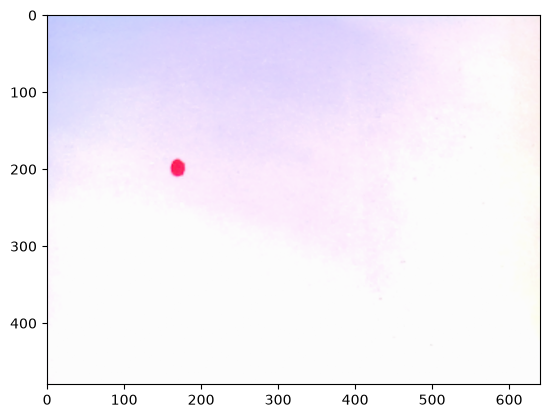

In [50]:
img1 = cam.capture_array("main")
# display image in pyplot
import matplotlib.pyplot as plt
plt.imshow(img1)
print (img1.shape)

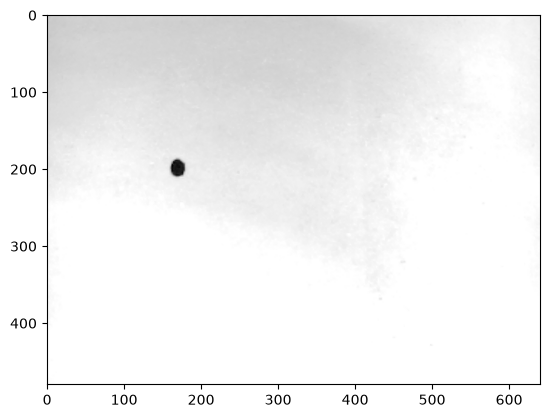

In [51]:
## Extract channel 1
ch = img1[:,:,1]
plt.imshow(ch, cmap="gray")

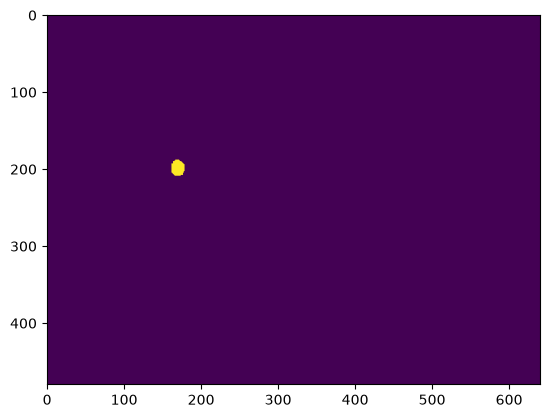

In [52]:
# threshold to keep only dark spot
spot = ch<100
plt.imshow(spot)

## get first point coordinates

In [53]:
import numpy as np
y,x = np.where(spot)
cy = np.mean(y)
cx = np.mean(x)
point_a =(cx,cy)
point_a

(np.float64(169.80405405405406), np.float64(198.41554054054055))

## Move camera by known amount

In [54]:
distance = -20
s.move_relative(distance,0,0)

## repeat localize second point

In [55]:
img2 = cam.capture_array("main")
spot = img2[:,:,1]<100
y,x = np.where(spot)
cy = np.mean(y)
cx = np.mean(x)
point_b =(cx,cy)

## Show results

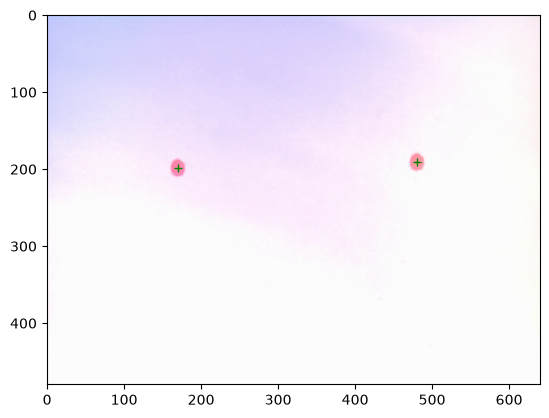

In [56]:

plt.imshow(img2)
plt.imshow(img1, alpha=0.5)

plt.plot(point_a[0],point_a[1], marker="+", color="green")
plt.plot(point_b[0],point_b[1], marker="+", color="green")

In [57]:
import math 
pixel_distance = math.dist(point_a,point_b)
pixel_size = abs(distance)/pixel_distance
print (f"Distance in pixels: {pixel_distance}")
print (f"Real world distance: {abs(distance)}")
print (f"Pixel size in units: {pixel_size}")

Distance in pixels: 310.43195010668114
Real world distance: 20
Pixel size in units: 0.06442635815394299


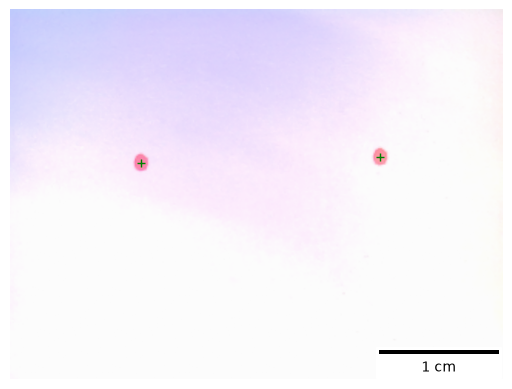

In [58]:
from matplotlib_scalebar.scalebar import ScaleBar

# Create subplot
fig, ax = plt.subplots()
ax.axis("off")

ax.imshow(img2)
ax.imshow(img1, alpha=0.5)

ax.plot(point_a[0],point_a[1], marker="+", color="green")
ax.plot(point_b[0],point_b[1], marker="+", color="green")

# Create scale bar
scalebar = ScaleBar(pixel_size, "mm", length_fraction=0.33, location="lower right", fixed_units="mm")
ax.add_artist(scalebar)

plt.show()

# see https://github.com/ppinard/matplotlib-scalebar for all scalebar options

## Saving images with tiff calibration

In [59]:
from tifffile import imwrite
imwrite('temp.tif', 
        img2, 
        imagej=True, 
        resolution=(1./pixel_size, 1./pixel_size),
        metadata={ 'unit': 'mm'}
       )
